# Molecular Mechanics / Molecular Dynamics  
## Motivation: From Forces to Motion
 
The emphasis is on the transition from **potential energy functions** to **equations of motion** and then to **molecular dynamics trajectories**.

---

## Learning goals

By the end of this lesson, you should be able to:

1. Explain how forces are obtained from a molecular mechanics potential energy function.
2. State Newton's equations of motion and describe their role in MD.
3. Understand the basic idea of numerical integration in molecular dynamics.
4. Contrast Newtonian dynamics with Langevin dynamics.
5. Explain why solvation matters and distinguish between explicit and implicit solvent.

## Big picture: from energy to motion

In molecular mechanics, we define a potential energy function

\begin{equation}
E(\mathbf{r})
\end{equation}

where $\mathbf{r}$ represents all atomic coordinates.

Once the energy is known, the **force** on atom $i$ is

\begin{equation}
\mathbf{F}_i = -\nabla_i E(\mathbf{r}).
\end{equation}

This is the key bridge from **molecular mechanics** to **molecular dynamics**:

- **MM:** gives us the energy of a structure
- **MD:** uses the forces from that energy to move the atoms in time

## Typical molecular mechanics energy function

A standard force field writes the total potential energy as a sum of bonded and nonbonded terms:

\begin{equation}
E = E_{\text{bond}} + E_{\text{angle}} + E_{\text{dihedral}} + E_{\text{vdW}} + E_{\text{elec}}
\end{equation}

For example:

\begin{equation}
E_{\text{bond}} = \sum_{\text{bonds}} k_b (r-r_0)^2
\end{equation}

\begin{equation}
E_{\text{angle}} = \sum_{\text{angles}} k_\theta (\theta-\theta_0)^2
\end{equation}

\begin{equation}
E_{\text{dihedral}} = \sum_{\text{dihedrals}} \frac{V_n}{2}\left[1+\cos(n\phi-\delta)\right]
\end{equation}

\begin{equation}
E_{\text{vdW}} = \sum_{i<j} 4\epsilon_{ij}\left[\left(\frac{\sigma_{ij}}{r_{ij}}\right)^{12} - \left(\frac{\sigma_{ij}}{r_{ij}}\right)^6\right]
\end{equation}

\begin{equation}
E_{\text{elec}} = \sum_{i<j} \frac{q_i q_j}{4\pi \epsilon_0 r_{ij}}
\end{equation}

Each term contributes to the total force because the force is the **negative derivative** of the total energy.

## A simple 1D potential: force as the slope of the energy

To build intuition, let us start with a one-dimensional harmonic potential:

\begin{equation}
E(x) = \frac{1}{2}k(x-x_0)^2
\end{equation}

The corresponding force is

\begin{equation}
F(x) = -\frac{dE}{dx} = -k(x-x_0)
\end{equation}

So the force always points back toward the minimum at $x_0$.

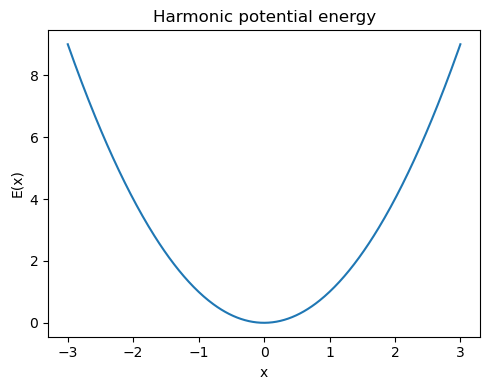

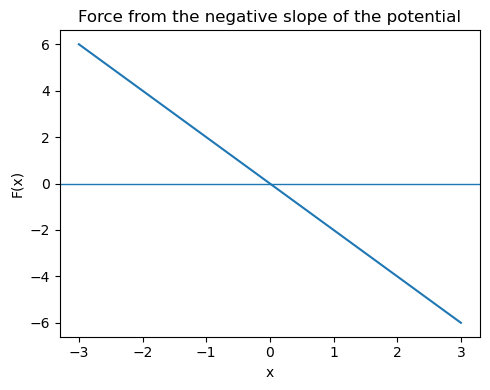

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Harmonic potential example
k = 2.0
x0 = 0.0
x = np.linspace(-3, 3, 400)
E = 0.5 * k * (x - x0)**2
F = -k * (x - x0)

plt.figure(figsize=(5,4))
plt.plot(x, E)
plt.xlabel("x")
plt.ylabel("E(x)")
plt.title("Harmonic potential energy")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.plot(x, F)
plt.axhline(0, linewidth=1)
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Force from the negative slope of the potential")
plt.tight_layout()
plt.show()

## Discussion questions

1. Where is the force zero?
2. Where is the energy minimum?
3. Why does the sign of the force change as the particle crosses the minimum?

## Newton's equations of motion

The foundation of classical molecular dynamics is Newton's second law:

\begin{equation}
m_i\frac{d^2\mathbf{r}_i}{dt^2} = \mathbf{F}_i
\end{equation}

or equivalently,

\begin{equation}
\mathbf{a}_i = \frac{\mathbf{F}_i}{m_i}
\end{equation}

This tells us that if we know:

- the current positions
- the current velocities
- the forces on each atom

then we can update the system forward in time.

In principle, the trajectory is deterministic: if the initial conditions are exactly known, the future motion is determined.

## Why numerical integration is needed

For real molecular systems, there is no closed-form solution for the motion of thousands of interacting atoms.  
Instead, MD uses a **small time step** and repeatedly updates positions and velocities.

A common algorithm is **velocity Verlet**.

### Velocity Verlet equations

\begin{equation}
\mathbf{r}(t+\Delta t) = \mathbf{r}(t) + \mathbf{v}(t)\Delta t + \frac{1}{2}\mathbf{a}(t)\Delta t^2
\end{equation}

Then forces are recomputed at the new positions, giving \(\mathbf{a}(t+\Delta t)\), and velocities are updated by

\begin{equation}
\mathbf{v}(t+\Delta t) = \mathbf{v}(t) + \frac{1}{2}\left[\mathbf{a}(t)+\mathbf{a}(t+\Delta t)\right]\Delta t
\end{equation}

Typical MD time steps are around **1-2 fs** for atomistic simulations.

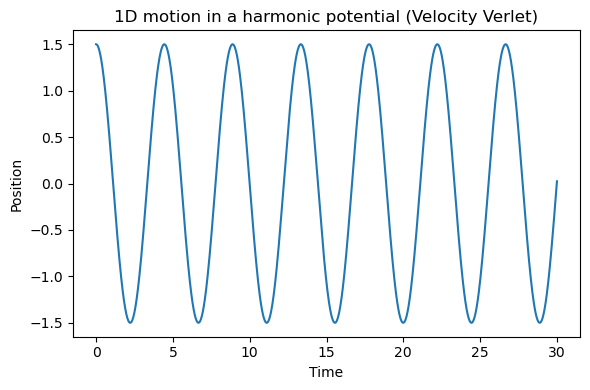

In [2]:
def velocity_verlet_1d(force_func, x0, v0, m, dt, nsteps):
    xs = np.zeros(nsteps + 1)
    vs = np.zeros(nsteps + 1)
    ts = np.arange(nsteps + 1) * dt

    xs[0] = x0
    vs[0] = v0

    a = force_func(x0) / m

    for i in range(nsteps):
        xs[i+1] = xs[i] + vs[i]*dt + 0.5*a*dt**2
        a_new = force_func(xs[i+1]) / m
        vs[i+1] = vs[i] + 0.5*(a + a_new)*dt
        a = a_new

    return ts, xs, vs

# Harmonic force F = -k(x-x0)
def harmonic_force(x, k=2.0, xeq=0.0):
    return -k * (x - xeq)

m = 1.0
dt = 0.02
nsteps = 1500

teval, xpos, vpos = velocity_verlet_1d(harmonic_force, x0=1.5, v0=0.0, m=m, dt=dt, nsteps=nsteps)

plt.figure(figsize=(6,4))
plt.plot(teval, xpos)
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("1D motion in a harmonic potential (Velocity Verlet)")
plt.tight_layout()
plt.show()

### What do you observe?

This motion is oscillatory because the harmonic potential is a restoring potential.  
In an ideal Newtonian system with a stable integration time step, the particle repeatedly moves back and forth through the minimum.

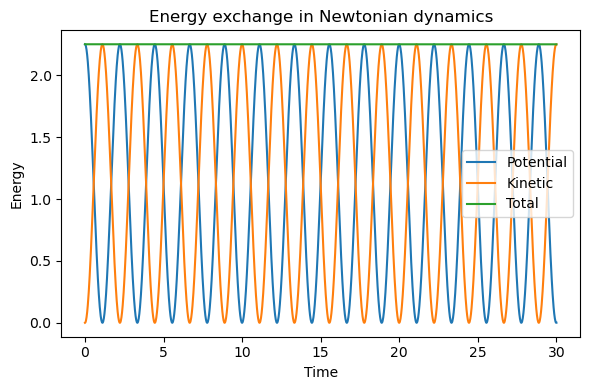

In [3]:
# Plot kinetic, potential, and total energy for the harmonic trajectory
k = 2.0
potential = 0.5 * k * xpos**2
kinetic = 0.5 * m * vpos**2
total = potential + kinetic

plt.figure(figsize=(6,4))
plt.plot(teval, potential, label="Potential")
plt.plot(teval, kinetic, label="Kinetic")
plt.plot(teval, total, label="Total")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.title("Energy exchange in Newtonian dynamics")
plt.legend()
plt.tight_layout()
plt.show()

## Interpreting Newtonian MD

Pure Newtonian dynamics corresponds most closely to the **microcanonical ensemble (NVE)**:

- **N** = number of particles fixed
- **V** = volume fixed
- **E** = total energy fixed

In this picture, energy is not exchanged with an external heat bath.

This is conceptually clean and physically important, but it is not always the most convenient description of a biomolecule in solution at constant temperature.

## Why Newtonian dynamics is often not enough

Real molecular systems, especially biomolecules, are usually not isolated.

For example, a protein in water experiences:

- continual collisions with solvent molecules
- friction-like dissipation
- random thermal kicks
- exchange of energy with the environment

This motivates other equations of motion, especially **Langevin dynamics**.

## Langevin dynamics

A common form of the Langevin equation is

\begin{equation}
m\frac{d^2x}{dt^2} = F(x) - \gamma v + R(t)
\end{equation}

where

- $F(x)$ is the deterministic force from the potential energy function
- $-\gamma v$ is a friction term
- $R(t)$ is a random force representing thermal noise

### Interpretation

Langevin dynamics adds two effects that pure Newtonian dynamics does not include:

1. **Damping** from the environment
2. **Random kicks** from thermal motion of the surroundings

This makes Langevin dynamics especially useful for simulations meant to represent molecules in a solvent bath at roughly constant temperature.

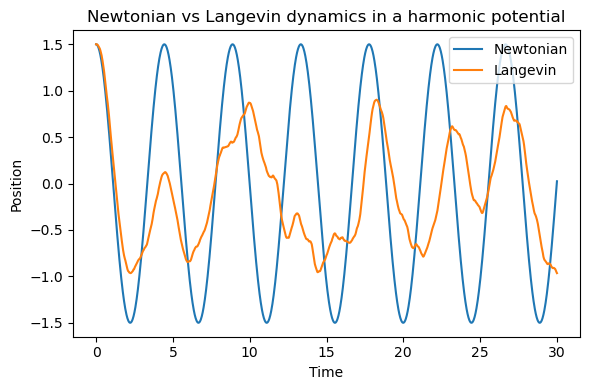

In [4]:
def langevin_dynamics_1d(force_func, x0, v0, m, gamma, kT, dt, nsteps, seed=0):
    rng = np.random.default_rng(seed)
    xs = np.zeros(nsteps + 1)
    vs = np.zeros(nsteps + 1)
    ts = np.arange(nsteps + 1) * dt

    xs[0] = x0
    vs[0] = v0

    sigma = np.sqrt(2 * gamma * kT / m)

    for i in range(nsteps):
        F = force_func(xs[i])
        noise = sigma * np.sqrt(dt) * rng.normal()
        a_eff = (F / m) - gamma * vs[i]
        vs[i+1] = vs[i] + a_eff * dt + noise
        xs[i+1] = xs[i] + vs[i+1] * dt

    return ts, xs, vs

teval_L, xpos_L, vpos_L = langevin_dynamics_1d(
    harmonic_force, x0=1.5, v0=0.0, m=1.0, gamma=0.8, kT=0.5, dt=0.02, nsteps=1500, seed=1
)

plt.figure(figsize=(6,4))
plt.plot(teval, xpos, label="Newtonian")
plt.plot(teval_L, xpos_L, label="Langevin")
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Newtonian vs Langevin dynamics in a harmonic potential")
plt.legend()
plt.tight_layout()
plt.show()

### Discussion

Compared with Newtonian dynamics, the Langevin trajectory typically shows:

- damping of coherent oscillations
- noisy fluctuations
- behavior more reminiscent of motion in a solvent environment

This is one reason Langevin dynamics is so common in biomolecular simulation.

## Newtonian vs Langevin dynamics

### Newtonian dynamics

**Advantages**
- clean physical foundation
- deterministic trajectory from initial conditions
- natural connection to conservation of total energy

**Limitations**
- no heat bath
- no solvent friction unless solvent atoms are explicitly present
- not the most convenient way to maintain temperature

### Langevin dynamics

**Advantages**
- incorporates environmental damping and noise
- useful for temperature control
- often numerically stable and practical for biomolecular systems

**Limitations**
- no longer purely deterministic
- strong damping can distort dynamical timescales

A good classroom message is:

> Newtonian dynamics is the fundamental starting point; Langevin dynamics is a practical extension that often better represents molecules in a thermal environment.

## Connecting solvation and dynamics

There is an important conceptual connection here:

- With **explicit solvent**, the water molecules themselves generate collisions and friction-like effects.
- With **implicit solvent**, those microscopic solvent collisions are absent, so **Langevin dynamics** is often used to mimic them.

This gives a very useful teaching narrative:

> Pure Newtonian dynamics is the basic engine.  
> Solvent and thermostats help make the simulation look more like a real laboratory environment.